# 📊 Analisis Penggabungan Dataset: HAM10000, ISIC 2017, & ISIC 2019
### Eksplorasi Total Kelas, Sebaran Diagnosis Medis, dan Audit Deduplikasi Lintas-Dataset

---
Notebook ini dibuat khusus untuk:
1. **Menggabungkan seluruh data** dari 3 dataset utama: HAM10000, ISIC 2017, dan ISIC 2019 (baik Train, Val, maupun Test).
2. **Memeriksa total seluruh kelas** yang ada pada data gabungan tersebut (baik nama diagnosis asli maupun kelas terharmonisasi).
3. **Menganalisis perbandingan total kelas** pada kondisi **RAW (sebelum deduplikasi)** vs **BERSIH (setelah deduplikasi)**.
4. **Menyajikan tabel matriks silang (cross-tabulation)** dan grafik visualisasi sebaran kelas per sumber dataset.
5. **Mengekspor data gabungan** ke file CSV siap pakai: `Dataset/dataset_gabungan_ham10k_2017_2019.csv`.


## Langkah 1 — Setup Library & Load Seluruh Data Sumber
Memuat 6 sumber partisi dari 3 dataset utama:
* **HAM10000:** 10.015 citra
* **ISIC 2019:** 25.331 citra Training + 8.238 citra Test = **33.569 citra**
* **ISIC 2017:** 2.000 citra Training + 150 citra Validation + 600 citra Test = **2.750 citra**
* **Total Citra Mentah (RAW):** **46.334 citra**


In [1]:
import os
import glob
import warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')
plt.rcParams['font.sans-serif'] = 'Arial'

# Deteksi lokasi folder Dataset
folder_aktif = os.getcwd()
if os.path.exists(os.path.join(folder_aktif, 'Dataset')):
    ROOT = os.path.join(folder_aktif, 'Dataset')
elif os.path.exists(os.path.join(os.path.dirname(folder_aktif), 'Dataset')):
    ROOT = os.path.join(os.path.dirname(folder_aktif), 'Dataset')
else:
    ROOT = r"C:\Users\ARII\Downloads\Data Understanding Isic & Ham10k\Dataset"

print(f"Folder Dataset aktif: {ROOT}")

# Konfigurasi 6 sumber dataset
SOURCES = {
    'ham10000': {
        'year': '2018', 'split': 'train', 'gt_format': 'ham_dx',
        'img_dirs': [
            os.path.join(ROOT, 'HAM10K', 'HAM10000_images_part_1'),
            os.path.join(ROOT, 'HAM10K', 'HAM10000_images_part_2'),
        ],
        'gt_path': os.path.join(ROOT, 'HAM10K', 'HAM10000_metadata'),
    },
    'isic_2019_train': {
        'year': '2019', 'split': 'train', 'gt_format': 'onehot9',
        'img_dir': os.path.join(ROOT, 'isic 2019', 'ISIC_2019_Training_Input', 'ISIC_2019_Training_Input'),
        'gt_path': os.path.join(ROOT, 'isic 2019', 'ISIC_2019_Training_Input', 'ISIC_2019_Training_GroundTruth.csv'),
    },
    'isic_2019_test': {
        'year': '2019', 'split': 'test', 'gt_format': 'onehot9',
        'img_dir': os.path.join(ROOT, 'isic 2019', 'ISIC_2019_Test_Input', 'ISIC_2019_Test_Input'),
        'gt_path': os.path.join(ROOT, 'isic 2019', 'ISIC_2019_Test_Input', 'ISIC_2019_Test_GroundTruth.csv'),
    },
    'isic_2017_train': {
        'year': '2017', 'split': 'train', 'gt_format': '2017',
        'img_dir': os.path.join(ROOT, 'isic 2017', 'ISIC-2017_Training_Data', 'ISIC-2017_Training_Data'),
        'gt_path': os.path.join(ROOT, 'isic 2017', 'ISIC-2017_Training_Data', 'ISIC-2017_Training_Part3_GroundTruth.csv'),
    },
    'isic_2017_val': {
        'year': '2017', 'split': 'val', 'gt_format': '2017',
        'img_dir': os.path.join(ROOT, 'isic 2017', 'ISIC-2017_Validation_Data', 'ISIC-2017_Validation_Data'),
        'gt_path': os.path.join(ROOT, 'isic 2017', 'ISIC-2017_Validation_Data', 'ISIC-2017_Validation_Part3_GroundTruth.csv'),
    },
    'isic_2017_test': {
        'year': '2017', 'split': 'test', 'gt_format': '2017',
        'img_dir': os.path.join(ROOT, 'isic 2017', 'ISIC-2017_Test_v2_Data', 'ISIC-2017_Test_v2_Data'),
        'gt_path': os.path.join(ROOT, 'isic 2017', 'ISIC-2017_Test_v2_Data', 'ISIC-2017_Test_v2_Part3_GroundTruth.csv'),
    },
}

print(f"Total sumber dataset terdaftar: {len(SOURCES)}")

# Pindai file citra fisik
IMG_EXT = ('.jpg', '.jpeg')
all_images = []

for source, info in SOURCES.items():
    if 'img_dirs' in info:
        for d in info['img_dirs']:
            if os.path.exists(d):
                for f in os.listdir(d):
                    if f.lower().endswith(IMG_EXT):
                        all_images.append({'image_id': os.path.splitext(f)[0], 'source': source, 'filepath': os.path.join(d, f)})
    else:
        d = info.get('img_dir')
        if d and os.path.exists(d):
            for root_dir, _, files in os.walk(d):
                if '__MACOSX' in root_dir:
                    continue
                for f in files:
                    if f.lower().endswith(IMG_EXT) and not f.startswith('._'):
                        all_images.append({'image_id': os.path.splitext(f)[0], 'source': source, 'filepath': os.path.join(root_dir, f)})

df_images = pd.DataFrame(all_images)

# Pemuatan ground truth independen per sumber (menjaga label asli murni)
source_label_maps = {}
for source, info in SOURCES.items():
    p = info.get('gt_path')
    fmt = info.get('gt_format')
    if not p or not os.path.exists(p):
        continue
    
    df_gt = pd.read_csv(p)
    id_col = next((c for c in ['image_id', 'image', 'image_name', 'isic_id'] if c in df_gt.columns), df_gt.columns[0])
    df_gt['image_id'] = df_gt[id_col].astype(str).str.replace('.jpg', '', regex=False)
    
    m = {}
    if fmt == 'ham_dx':
        for _, row in df_gt.iterrows():
            m[row['image_id']] = str(row['dx']).lower()
    elif fmt == '2017':
        for _, row in df_gt.iterrows():
            if row.get('melanoma') == 1.0:
                m[row['image_id']] = 'melanoma'
            elif row.get('seborrheic_keratosis') == 1.0:
                m[row['image_id']] = 'seborrheic_keratosis'
            else:
                m[row['image_id']] = 'nevus'
    elif fmt == 'onehot9':
        cols = [c for c in df_gt.columns if c not in ('image_id', id_col, 'score_weight', 'validation_weight')]
        for _, row in df_gt.iterrows():
            assigned = None
            for c in cols:
                if row.get(c) == 1.0:
                    assigned = c
                    break
            if assigned:
                m[row['image_id']] = assigned
    source_label_maps[source] = m

df_images['original_label'] = df_images.apply(lambda r: source_label_maps.get(r['source'], {}).get(r['image_id']), axis=1)

def get_group(src):
    if 'ham10000' in src:
        return 'HAM10000'
    elif '2019' in src:
        return 'ISIC 2019'
    elif '2017' in src:
        return 'ISIC 2017'
    return src

df_images['dataset_group'] = df_images['source'].apply(get_group)

print(f"Gambar fisik terindeks : {len(df_images):,} citra")
print(f"Gambar berlabel ground truth: {df_images['original_label'].notna().sum():,} citra")


Folder Dataset aktif: C:\Users\ARII\Downloads\Data Understanding Isic & Ham10k\Dataset
Total sumber dataset terdaftar: 6
Gambar fisik terindeks : 46,334 citra
Gambar berlabel ground truth: 46,334 citra


## Langkah 2 — Harmonisasi Sinonim Label Medis Menjadi 1 Standar Diagnosis
Masing-masing dataset menggunakan konvensi penamaan yang berbeda:
* HAM10000 menggunakan singkatan huruf kecil (`nv`, `mel`, `bkl`, `bcc`, `akiec`, `vasc`, `df`).
* ISIC 2019 menggunakan singkatan huruf besar (`NV`, `MEL`, `BCC`, `BKL`, `AK`, `SCC`, `VASC`, `DF`, `UNK`).
* ISIC 2017 menggunakan kata bahasa Inggris lengkap (`nevus`, `melanoma`, `seborrheic_keratosis`).

Seluruh label tersebut disatukan ke dalam **9 KELAS MEDIS STANDAR** (`NV`, `MEL`, `BCC`, `BKL`, `AKIEC`, `SCC`, `VASC`, `DF`, `UNK`).


In [2]:
# Kamus aturan harmonisasi label medis
LABEL_HARMONIZATION = {
    'nv': 'NV', 'nevus': 'NV', 'NV': 'NV',
    'mel': 'MEL', 'melanoma': 'MEL', 'MEL': 'MEL',
    'bkl': 'BKL', 'seborrheic_keratosis': 'BKL', 'BKL': 'BKL',
    'bcc': 'BCC', 'BCC': 'BCC',
    'akiec': 'AKIEC', 'ak': 'AKIEC', 'AK': 'AKIEC',
    'vasc': 'VASC', 'VASC': 'VASC',
    'df': 'DF', 'DF': 'DF',
    'scc': 'SCC', 'SCC': 'SCC',
    'unk': 'UNK', 'UNK': 'UNK'
}

df_images['unified_class'] = df_images['original_label'].map(LABEL_HARMONIZATION)

# Tampilkan ringkasan kamus harmonisasi
df_rules_view = pd.DataFrame([
    {'Kode Standar': 'NV', 'Variasi Penamaan': 'nv, nevus, NV', 'Nama Medis': 'Melanocytic Nevus', 'Kategori': 'Benign (Jinak)'},
    {'Kode Standar': 'MEL', 'Variasi Penamaan': 'mel, melanoma, MEL', 'Nama Medis': 'Melanoma', 'Kategori': 'Malignant (Ganas)'},
    {'Kode Standar': 'BCC', 'Variasi Penamaan': 'bcc, BCC', 'Nama Medis': 'Basal Cell Carcinoma', 'Kategori': 'Malignant (Ganas)'},
    {'Kode Standar': 'BKL', 'Variasi Penamaan': 'bkl, seborrheic_keratosis, BKL', 'Nama Medis': 'Benign Keratosis', 'Kategori': 'Benign (Jinak)'},
    {'Kode Standar': 'AKIEC', 'Variasi Penamaan': 'akiec, ak, AK', 'Nama Medis': 'Actinic Keratosis', 'Kategori': 'Malignant / Pre-cancer'},
    {'Kode Standar': 'SCC', 'Variasi Penamaan': 'scc, SCC', 'Nama Medis': 'Squamous Cell Carcinoma', 'Kategori': 'Malignant (Ganas)'},
    {'Kode Standar': 'VASC', 'Variasi Penamaan': 'vasc, VASC', 'Nama Medis': 'Vascular Lesion', 'Kategori': 'Benign (Jinak)'},
    {'Kode Standar': 'DF', 'Variasi Penamaan': 'df, DF', 'Nama Medis': 'Dermatofibroma', 'Kategori': 'Benign (Jinak)'},
    {'Kode Standar': 'UNK', 'Variasi Penamaan': 'unk, UNK', 'Nama Medis': 'Unknown', 'Kategori': 'Out of Distribution'}
])
print("Tabel Kamus Harmonisasi Medis:")
display(df_rules_view)


Tabel Kamus Harmonisasi Medis:


Kode Standar,Variasi Penamaan,Nama Medis,Kategori
NV,"nv, nevus, NV",Melanocytic Nevus,Benign (Jinak)
MEL,"mel, melanoma, MEL",Melanoma,Malignant (Ganas)
BCC,"bcc, BCC",Basal Cell Carcinoma,Malignant (Ganas)
BKL,"bkl, seborrheic_keratosis, BKL",Benign Keratosis,Benign (Jinak)
AKIEC,"akiec, ak, AK",Actinic Keratosis,Malignant / Pre-cancer
SCC,"scc, SCC",Squamous Cell Carcinoma,Malignant (Ganas)
VASC,"vasc, VASC",Vascular Lesion,Benign (Jinak)
DF,"df, DF",Dermatofibroma,Benign (Jinak)
UNK,"unk, UNK",Unknown,Out of Distribution


## Langkah 3 — Analisis Total Kelas pada Data Mentah Gabungan (RAW — 46.334 Citra)
Sebelum dilakukan pembersihan duplikat, berikut adalah sebaran total 9 kelas pada seluruh data mentah gabungan HAM10000, ISIC 2017, dan ISIC 2019:


In [3]:
# Tabel Silang (Cross-Tabulation) Data Mentah Gabungan
ORDERED_CLASSES = ['NV', 'MEL', 'BCC', 'BKL', 'AKIEC', 'SCC', 'VASC', 'DF', 'UNK']
ct_raw = pd.crosstab(df_images['unified_class'], df_images['dataset_group'])
tot_raw = len(df_images)

rows_raw_ct = []
for cls in ORDERED_CLASSES:
    n_ham = int(ct_raw.loc[cls, 'HAM10000']) if 'HAM10000' in ct_raw.columns and cls in ct_raw.index else 0
    n_19  = int(ct_raw.loc[cls, 'ISIC 2019']) if 'ISIC 2019' in ct_raw.columns and cls in ct_raw.index else 0
    n_17  = int(ct_raw.loc[cls, 'ISIC 2017']) if 'ISIC 2017' in ct_raw.columns and cls in ct_raw.index else 0
    n_tot = n_ham + n_19 + n_17
    dname, desc, target = UNIFIED_INFO.get(cls, (cls, '-', '-'))
    rows_raw_ct.append({
        'Kelas Standar': cls,
        'Nama Diagnosis Medis': dname,
        'HAM10000': f"{n_ham:,}",
        'ISIC 2019': f"{n_19:,}",
        'ISIC 2017': f"{n_17:,}",
        'Total RAW': f"{n_tot:,}",
        '% Proporsi': f"{n_tot / tot_raw * 100:.2f}%",
        'Kategori Medis': target
    })

rows_raw_ct.append({
    'Kelas Standar': 'TOTAL RAW',
    'Nama Diagnosis Medis': 'Seluruh Data Mentah Gabungan',
    'HAM10000': f"{(df_images['dataset_group'] == 'HAM10000').sum():,}",
    'ISIC 2019': f"{(df_images['dataset_group'] == 'ISIC 2019').sum():,}",
    'ISIC 2017': f"{(df_images['dataset_group'] == 'ISIC 2017').sum():,}",
    'Total RAW': f"{tot_raw:,}",
    '% Proporsi': '100.0%',
    'Kategori Medis': '-'
})
df_raw_summary = pd.DataFrame(rows_raw_ct)
print("=== TABEL SILANG DISTRIBUSI KELAS: DATA MENTAH GABUNGAN (46.334 CITRA RAW) ===")
display(df_raw_summary)


=== TABEL SILANG DISTRIBUSI KELAS: DATA MENTAH GABUNGAN (46.334 CITRA RAW) ===


Kelas Standar,Nama Diagnosis Medis,HAM10000,ISIC 2019,ISIC 2017,Total RAW,% Proporsi,Kategori Medis
NV,Melanocytic Nevus,"6,705","15,370","1,843","23,918",51.62%,Benign (0)
MEL,Melanoma,"1,113","5,849",521,"7,483",16.15%,Malignant (1)
BCC,Basal Cell Carcinoma,514,"4,298",0,"4,812",10.39%,Malignant (1)
BKL,Benign Keratosis,"1,099","3,284",386,"4,769",10.29%,Benign (0)
AKIEC,Actinic Keratosis,327,"1,241",0,"1,568",3.38%,Malignant (1)
SCC,Squamous Cell Carcinoma,0,793,0,793,1.71%,Malignant (1)
VASC,Vascular Lesion,142,357,0,499,1.08%,Benign (0)
DF,Dermatofibroma,115,330,0,445,0.96%,Benign (0)
UNK,Unknown,0,"2,047",0,"2,047",4.42%,Out of Distribution
TOTAL RAW,Seluruh Data Mentah Gabungan,"10,015","33,569","2,750","46,334",100.0%,-


## Langkah 4 — Deduplikasi Data Lintas-Dataset (Prioritas HAM10000)
Karena dataset ISIC 2019 dan 2017 mengimpor citra dari HAM10000, terdapat **10.735 citra kembar (duplikat)** yang harus dibersihkan:
* **HAM10000:** Dipertahankan 100% utuh (**10.015 citra**).
* **ISIC 2019:** Sebanyak 10.015 citra duplikat dibuang $\rightarrow$ tersisa **23.554 citra unik**.
* **ISIC 2017:** Sebanyak 720 citra duplikat dibuang $\rightarrow$ tersisa **2.030 citra unik**.
* **Total Citra Bersih Bebas Duplikat:** **35.599 citra**.


In [4]:
# Prioritas deduplikasi: HAM10000 > ISIC 2019 > ISIC 2017
PRIORITY_ORDER = ['ham10000', 'isic_2019_train', 'isic_2019_test', 'isic_2017_train', 'isic_2017_val', 'isic_2017_test']
priority_map = {src: i for i, src in enumerate(PRIORITY_ORDER)}
df_images['priority'] = df_images['source'].map(priority_map)

df_sorted = df_images.sort_values(by=['image_id', 'priority'])
df_clean = df_sorted.drop_duplicates(subset='image_id', keep='first').copy()
df_dropped = df_sorted[~df_sorted.index.isin(df_clean.index)].copy()
kept_map = df_clean.set_index('image_id')['source'].to_dict()
df_dropped['kept_in_source'] = df_dropped['image_id'].map(kept_map)

before_counts = df_images['source'].value_counts()
after_counts = df_clean['source'].value_counts()
dropped_counts = df_dropped['source'].value_counts()

rows_dedup = []
for src in PRIORITY_ORDER:
    b = before_counts.get(src, 0)
    a = after_counts.get(src, 0)
    d = dropped_counts.get(src, 0)
    pct = round((d / b * 100), 2) if b > 0 else 0
    dropped_src = df_dropped[df_dropped['source'] == src]
    detail = "; ".join([f"{k} ({v:,})" for k, v in dropped_src['kept_in_source'].value_counts().items()]) if len(dropped_src) > 0 else "-"
    rows_dedup.append({'Source': src, 'Before (Raw)': f"{b:,}", 'Dropped (Duplikat)': f"{d:,}", 'After (Clean)': f"{a:,}", '% Drop': f"{pct}%", 'Kept In': detail})

df_dedup_table = pd.DataFrame(rows_dedup)
display(df_dedup_table)

print(f"\nTotal citra awal (RAW) : {len(df_images):,} citra")
print(f"Duplikat dibuang       : {len(df_dropped):,} citra")
print(f"Citra BERSIH tersisa   : {len(df_clean):,} citra")


Source,Before (Raw),Dropped (Duplikat),After (Clean),% Drop,Kept In
ham10000,"10,015",0,"10,015",0.0%,-
isic_2019_train,"25,331","10,015","15,316",39.54%,"ham10000 (10,015)"
isic_2019_test,"8,238",0,"8,238",0.0%,-
isic_2017_train,"2,000",717,"1,283",35.85%,isic_2019_train (717)
isic_2017_val,150,2,148,1.33%,isic_2019_train (2)
isic_2017_test,600,1,599,0.17%,isic_2019_train (1)



Total citra awal (RAW) : 46,334 citra
Duplikat dibuang       : 10,735 citra
Citra BERSIH tersisa   : 35,599 citra


## Langkah 5 — Analisis Total Kelas pada Data Bersih Gabungan (CLEAN — 35.599 Citra)
Setelah pembersihan duplikat, berikut adalah tabel matriks silang sebaran 9 kelas pada data bersih:


In [5]:
# Tabel Silang Data Bersih
ct_clean = pd.crosstab(df_clean['unified_class'], df_clean['dataset_group'])
tot_clean = len(df_clean)

rows_clean_ct = []
for cls in ORDERED_CLASSES:
    n_ham = int(ct_clean.loc[cls, 'HAM10000']) if 'HAM10000' in ct_clean.columns and cls in ct_clean.index else 0
    n_19  = int(ct_clean.loc[cls, 'ISIC 2019']) if 'ISIC 2019' in ct_clean.columns and cls in ct_clean.index else 0
    n_17  = int(ct_clean.loc[cls, 'ISIC 2017']) if 'ISIC 2017' in ct_clean.columns and cls in ct_clean.index else 0
    n_tot = n_ham + n_19 + n_17
    dname, desc, target = UNIFIED_INFO.get(cls, (cls, '-', '-'))
    rows_clean_ct.append({
        'Kelas Standar': cls,
        'Nama Diagnosis Medis': dname,
        'HAM10000': f"{n_ham:,}",
        'ISIC 2019': f"{n_19:,}",
        'ISIC 2017': f"{n_17:,}",
        'Total Bersih': f"{n_tot:,}",
        '% Proporsi': f"{n_tot / tot_clean * 100:.2f}%",
        'Kategori Medis': target
    })

rows_clean_ct.append({
    'Kelas Standar': 'TOTAL BERSIH',
    'Nama Diagnosis Medis': 'Seluruh Data Bersih Bebas Duplikat',
    'HAM10000': f"{(df_clean['dataset_group'] == 'HAM10000').sum():,}",
    'ISIC 2019': f"{(df_clean['dataset_group'] == 'ISIC 2019').sum():,}",
    'ISIC 2017': f"{(df_clean['dataset_group'] == 'ISIC 2017').sum():,}",
    'Total Bersih': f"{tot_clean:,}",
    '% Proporsi': '100.0%',
    'Kategori Medis': '-'
})
df_clean_summary = pd.DataFrame(rows_clean_ct)
print("=== TABEL SILANG DISTRIBUSI KELAS: DATA BERSIH GABUNGAN (35.599 CITRA CLEAN) ===")
display(df_clean_summary)

# Perbandingan Raw vs Clean
comp_rows = []
for cls in ORDERED_CLASSES:
    c_raw = int((df_images['unified_class'] == cls).sum())
    c_cln = int((df_clean['unified_class'] == cls).sum())
    c_drop = c_raw - c_cln
    dname, _, target = UNIFIED_INFO.get(cls, (cls, '-', '-'))
    comp_rows.append({
        'Kelas': cls,
        'Nama Diagnosis': dname,
        'Jumlah RAW (46.334)': f"{c_raw:,} ({c_raw/tot_raw*100:.2f}%)",
        'Duplikat Dibuang': f"{c_drop:,}",
        'Jumlah BERSIH (35.599)': f"{c_cln:,} ({c_cln/tot_clean*100:.2f}%)",
        'Kategori Target': target
    })
df_comp_table = pd.DataFrame(comp_rows)
print("\n=== TABEL KOMPARASI JUMLAH KELAS: RAW vs BERSIH (EFEK DEDUPLIKASI) ===")
display(df_comp_table)


=== TABEL SILANG DISTRIBUSI KELAS: DATA BERSIH GABUNGAN (35.599 CITRA CLEAN) ===


Kelas Standar,Nama Diagnosis Medis,HAM10000,ISIC 2019,ISIC 2017,Total Bersih,% Proporsi,Kategori Medis
NV,Melanocytic Nevus,"6,705","8,665","1,273","16,643",46.75%,Benign (0)
MEL,Melanoma,"1,113","4,736",373,"6,222",17.48%,Malignant (1)
BCC,Basal Cell Carcinoma,514,"3,784",0,"4,298",12.07%,Malignant (1)
BKL,Benign Keratosis,"1,099","2,185",384,"3,668",10.30%,Benign (0)
AKIEC,Actinic Keratosis,327,"1,111",0,"1,438",4.04%,Malignant (1)
SCC,Squamous Cell Carcinoma,0,596,0,596,1.67%,Malignant (1)
VASC,Vascular Lesion,142,215,0,357,1.00%,Benign (0)
DF,Dermatofibroma,115,215,0,330,0.93%,Benign (0)
UNK,Unknown,0,"2,047",0,"2,047",5.75%,Out of Distribution
TOTAL BERSIH,Seluruh Data Bersih Bebas Duplikat,"10,015","23,554","2,030","35,599",100.0%,-



=== TABEL KOMPARASI JUMLAH KELAS: RAW vs BERSIH (EFEK DEDUPLIKASI) ===


Kelas,Nama Diagnosis,Jumlah RAW (46.334),Duplikat Dibuang,Jumlah BERSIH (35.599),Kategori Target
NV,Melanocytic Nevus,"23,918 (51.62%)","7,275","16,643 (46.75%)",Benign (0)
MEL,Melanoma,"7,483 (16.15%)","1,261","6,222 (17.48%)",Malignant (1)
BCC,Basal Cell Carcinoma,"4,812 (10.39%)",514,"4,298 (12.07%)",Malignant (1)
BKL,Benign Keratosis,"4,769 (10.29%)","1,101","3,668 (10.30%)",Benign (0)
AKIEC,Actinic Keratosis,"1,568 (3.38%)",130,"1,438 (4.04%)",Malignant (1)
SCC,Squamous Cell Carcinoma,793 (1.71%),197,596 (1.67%),Malignant (1)
VASC,Vascular Lesion,499 (1.08%),142,357 (1.00%),Benign (0)
DF,Dermatofibroma,445 (0.96%),115,330 (0.93%),Benign (0)
UNK,Unknown,"2,047 (4.42%)",0,"2,047 (5.75%)",Out of Distribution


## Langkah 6 — Visualisasi Grafik Distribusi Kelas Gabungan
Menampilkan perbandingan visual:
1. **Grafik Batang Perbandingan RAW vs BERSIH per Kelas**.
2. **Grouped Bar Chart Sebaran Kelas per Dataset Sumber**.
3. **Pie Chart Proporsi 8 Diagnosis Medis Pasti**.


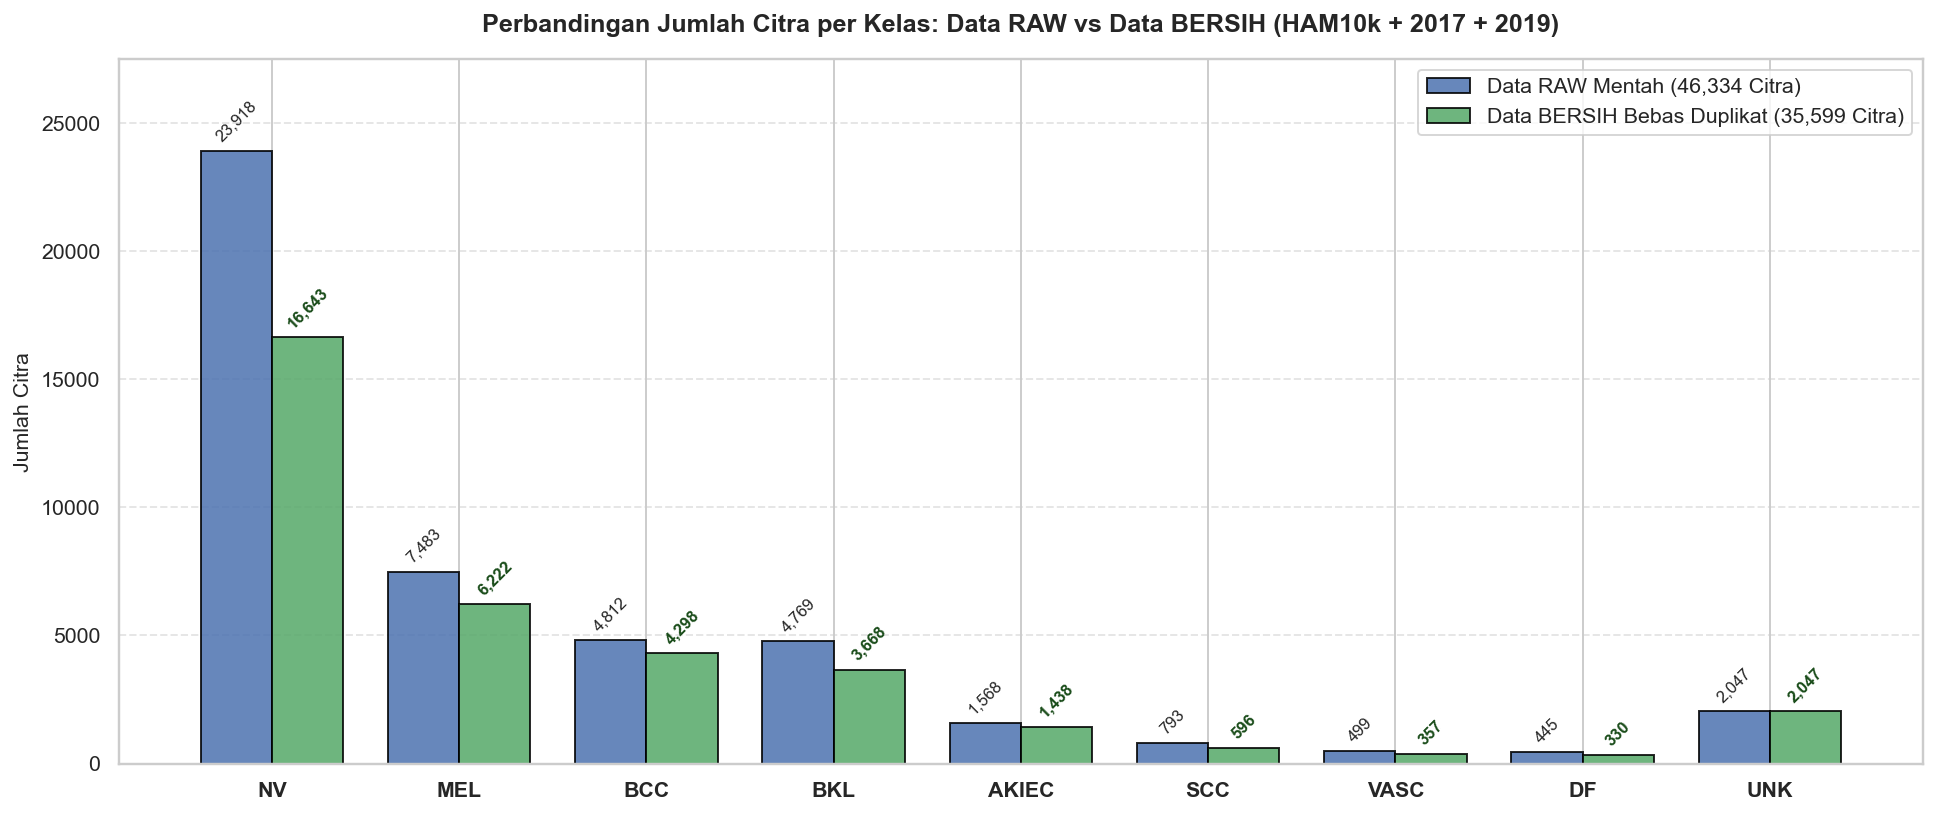

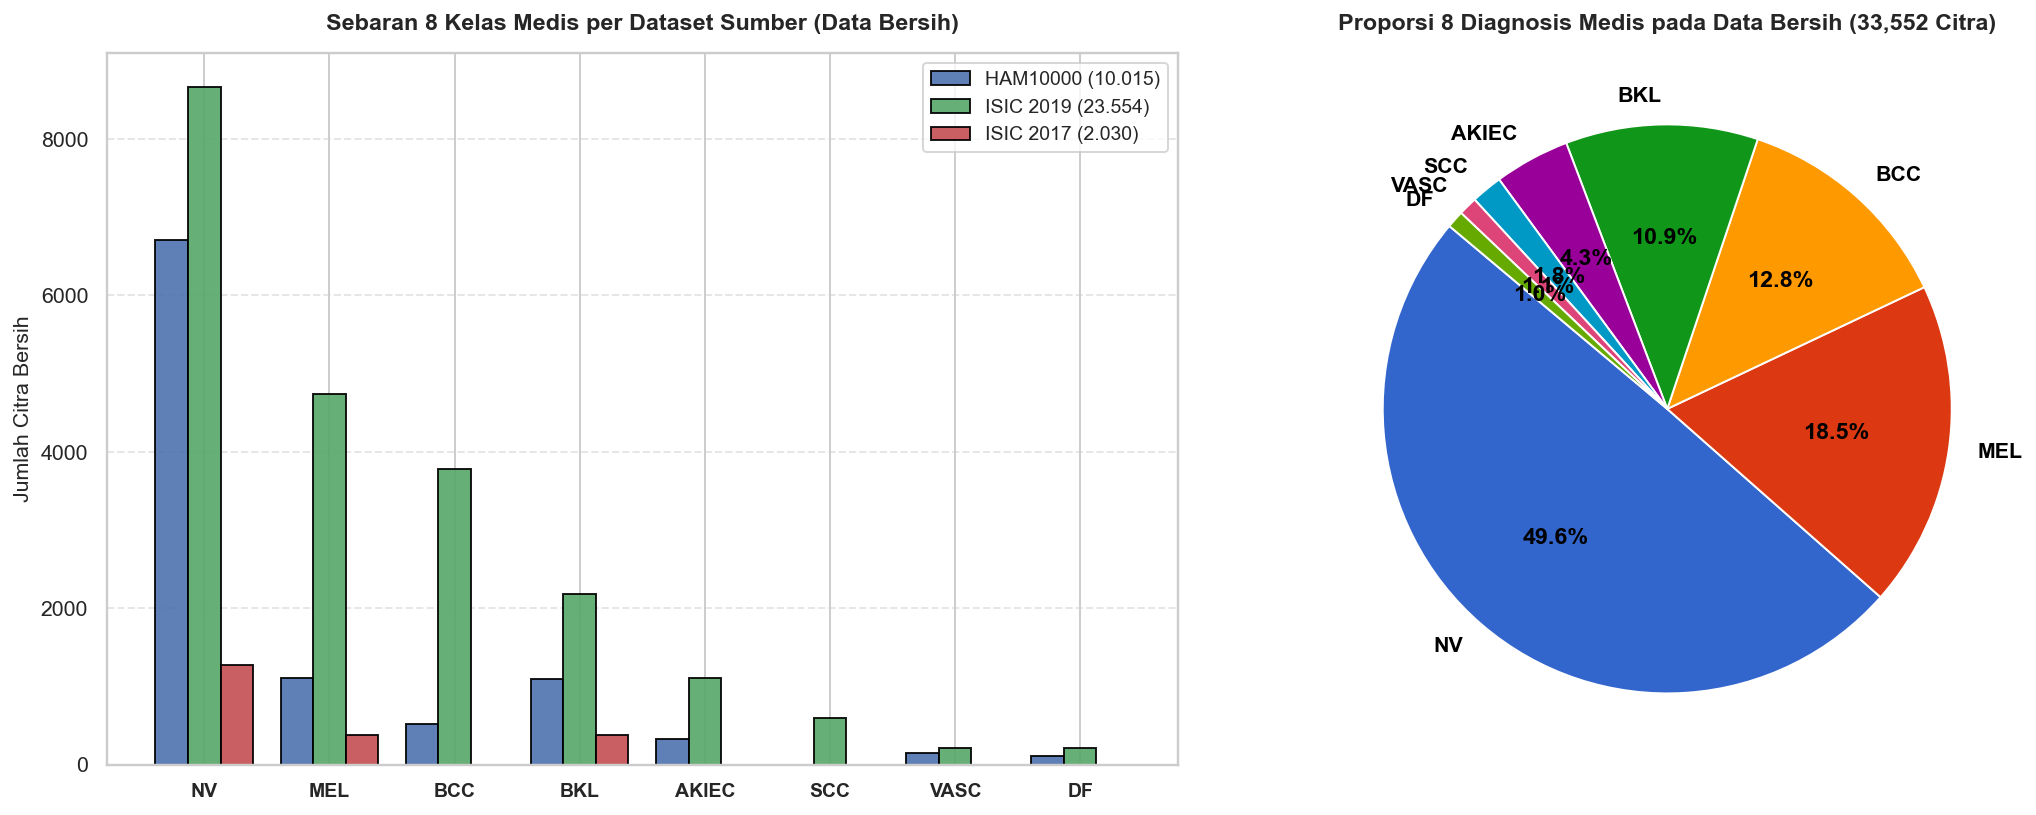

In [6]:
# 1. Visualisasi Perbandingan RAW vs BERSIH
fig1, ax1 = plt.subplots(figsize=(14, 6))
x_c = np.arange(len(ORDERED_CLASSES))
w = 0.38

raw_vals = [int((df_images['unified_class'] == c).sum()) for c in ORDERED_CLASSES]
cln_vals = [int((df_clean['unified_class'] == c).sum()) for c in ORDERED_CLASSES]

rect1 = ax1.bar(x_c - w/2, raw_vals, width=w, label=f'Data RAW Mentah ({tot_raw:,} Citra)', color='#4c72b0', edgecolor='black', alpha=0.85)
rect2 = ax1.bar(x_c + w/2, cln_vals, width=w, label=f'Data BERSIH Bebas Duplikat ({tot_clean:,} Citra)', color='#55a868', edgecolor='black', alpha=0.85)

ax1.set_xticks(x_c)
ax1.set_xticklabels(ORDERED_CLASSES, fontsize=11, fontweight='bold')
ax1.set_ylabel("Jumlah Citra", fontsize=11)
ax1.set_title("Perbandingan Jumlah Citra per Kelas: Data RAW vs Data BERSIH (HAM10k + 2017 + 2019)", fontsize=13, fontweight='bold', pad=14)
ax1.set_ylim(0, max(raw_vals) * 1.15)
ax1.legend(fontsize=11)
ax1.grid(axis='y', linestyle='--', alpha=0.5)

for r in rect1:
    h = r.get_height()
    ax1.text(r.get_x() + r.get_width()/2.0, h + 250, f"{int(h):,}", ha='center', va='bottom', fontsize=8.5, rotation=45)

for r in rect2:
    h = r.get_height()
    ax1.text(r.get_x() + r.get_width()/2.0, h + 250, f"{int(h):,}", ha='center', va='bottom', fontsize=8.5, rotation=45, fontweight='bold', color='#1b4d1b')

plt.tight_layout()
plt.show()

# 2. Breakdown Sebaran 8 Kelas per Dataset & Pie Chart
fig2, axes2 = plt.subplots(1, 2, figsize=(16, 6))

ax2_1 = axes2[0]
valid_8 = [c for c in ORDERED_CLASSES if c != 'UNK']
x_8 = np.arange(len(valid_8))
w8 = 0.26

ham_cnts = [int(((df_clean['dataset_group'] == 'HAM10000') & (df_clean['unified_class'] == c)).sum()) for c in valid_8]
isic19_cnts = [int(((df_clean['dataset_group'] == 'ISIC 2019') & (df_clean['unified_class'] == c)).sum()) for c in valid_8]
isic17_cnts = [int(((df_clean['dataset_group'] == 'ISIC 2017') & (df_clean['unified_class'] == c)).sum()) for c in valid_8]

ax2_1.bar(x_8 - w8, ham_cnts, width=w8, label='HAM10000 (10.015)', color='#4c72b0', edgecolor='black', alpha=0.9)
ax2_1.bar(x_8, isic19_cnts, width=w8, label='ISIC 2019 (23.554)', color='#55a868', edgecolor='black', alpha=0.9)
ax2_1.bar(x_8 + w8, isic17_cnts, width=w8, label='ISIC 2017 (2.030)', color='#c44e52', edgecolor='black', alpha=0.9)

ax2_1.set_xticks(x_8)
ax2_1.set_xticklabels(valid_8, fontsize=10, fontweight='bold')
ax2_1.set_ylabel("Jumlah Citra Bersih", fontsize=11)
ax2_1.set_title("Sebaran 8 Kelas Medis per Dataset Sumber (Data Bersih)", fontsize=12, fontweight='bold', pad=12)
ax2_1.legend(fontsize=10)
ax2_1.grid(axis='y', linestyle='--', alpha=0.5)

# Pie Chart
ax2_2 = axes2[1]
cln_8_vals = [int((df_clean['unified_class'] == c).sum()) for c in valid_8]
colors_pie = ['#3366cc', '#dc3912', '#ff9900', '#109618', '#990099', '#0099c6', '#dd4477', '#66aa00']
wedges, texts, autotexts = ax2_2.pie(
    cln_8_vals, labels=valid_8, autopct='%1.1f%%', startangle=140,
    colors=colors_pie, textprops=dict(color="black", fontweight='bold')
)
ax2_2.set_title(f"Proporsi 8 Diagnosis Medis pada Data Bersih ({sum(cln_8_vals):,} Citra)", fontsize=12, fontweight='bold', pad=12)

plt.tight_layout()
plt.show()


## Langkah 7 — Ekspor Dataset Gabungan Final
Menyimpan master dataset gabungan bersih ke dalam berkas CSV: `Dataset/dataset_gabungan_ham10k_2017_2019.csv`.


In [7]:
# Ekspor dataset gabungan bersih ke CSV
out_csv_path = os.path.join(ROOT, 'dataset_gabungan_ham10k_2017_2019.csv')
cols_exp = ['image_id', 'source', 'dataset_group', 'original_label', 'unified_class', 'filepath']

df_clean[cols_exp].to_csv(out_csv_path, index=False)

print(f"File CSV tersimpan : {out_csv_path}")
print(f"Total baris data   : {len(df_clean):,} baris")
print(f"Daftar kolom       : {', '.join(cols_exp)}")

display(df_clean[cols_exp].head(10))


File CSV tersimpan : C:\Users\ARII\Downloads\Data Understanding Isic & Ham10k\Dataset\dataset_gabungan_ham10k_2017_2019.csv
Total baris data   : 35,599 baris
Daftar kolom       : image_id, source, dataset_group, original_label, unified_class, filepath


image_id,source,dataset_group,original_label,unified_class,filepath
ISIC_0000000,isic_2019_train,ISIC 2019,NV,NV,C:\Users\ARII\Downloads\Data Understanding Isic & Ham10k\Dataset\isic 2019\ISIC_2019_Training_Input\ISIC_2019_Training_Input\ISIC_0000000.jpg
ISIC_0000001,isic_2019_train,ISIC 2019,NV,NV,C:\Users\ARII\Downloads\Data Understanding Isic & Ham10k\Dataset\isic 2019\ISIC_2019_Training_Input\ISIC_2019_Training_Input\ISIC_0000001.jpg
ISIC_0000002,isic_2019_train,ISIC 2019,MEL,MEL,C:\Users\ARII\Downloads\Data Understanding Isic & Ham10k\Dataset\isic 2019\ISIC_2019_Training_Input\ISIC_2019_Training_Input\ISIC_0000002.jpg
ISIC_0000003,isic_2019_train,ISIC 2019,NV,NV,C:\Users\ARII\Downloads\Data Understanding Isic & Ham10k\Dataset\isic 2019\ISIC_2019_Training_Input\ISIC_2019_Training_Input\ISIC_0000003.jpg
ISIC_0000004,isic_2019_train,ISIC 2019,MEL,MEL,C:\Users\ARII\Downloads\Data Understanding Isic & Ham10k\Dataset\isic 2019\ISIC_2019_Training_Input\ISIC_2019_Training_Input\ISIC_0000004.jpg
ISIC_0000006,isic_2019_train,ISIC 2019,NV,NV,C:\Users\ARII\Downloads\Data Understanding Isic & Ham10k\Dataset\isic 2019\ISIC_2019_Training_Input\ISIC_2019_Training_Input\ISIC_0000006.jpg
ISIC_0000007,isic_2019_train,ISIC 2019,NV,NV,C:\Users\ARII\Downloads\Data Understanding Isic & Ham10k\Dataset\isic 2019\ISIC_2019_Training_Input\ISIC_2019_Training_Input\ISIC_0000007.jpg
ISIC_0000008,isic_2019_train,ISIC 2019,NV,NV,C:\Users\ARII\Downloads\Data Understanding Isic & Ham10k\Dataset\isic 2019\ISIC_2019_Training_Input\ISIC_2019_Training_Input\ISIC_0000008.jpg
ISIC_0000009,isic_2019_train,ISIC 2019,NV,NV,C:\Users\ARII\Downloads\Data Understanding Isic & Ham10k\Dataset\isic 2019\ISIC_2019_Training_Input\ISIC_2019_Training_Input\ISIC_0000009.jpg
ISIC_0000010,isic_2019_train,ISIC 2019,NV,NV,C:\Users\ARII\Downloads\Data Understanding Isic & Ham10k\Dataset\isic 2019\ISIC_2019_Training_Input\ISIC_2019_Training_Input\ISIC_0000010.jpg


## 📌 Ringkasan Hasil & Kesimpulan Klinis

1. **Total Kelas:** Ditemukan tepat **9 KELAS MEDIS** yang mencakup seluruh spektrum lesi kulit pada ketiga dataset:
   * **Jinak (Benign):** `NV` (Tahi lalat), `BKL` (Keratosis seboroik), `DF` (Dermatofibroma), `VASC` (Lesi vaskular).
   * **Ganas (Malignant):** `MEL` (Melanoma), `BCC` (Karsinoma sel basal), `SCC` (Karsinoma sel skuamosa), `AKIEC` (Lesi pra-kanker keratinositik).
   * **Tanpa Label Pasti:** `UNK` (2.047 sampel khusus data uji ISIC 2019).
2. **Total Citra Gabungan:**
   * **RAW (Mentah):** **46.334 citra** (HAM10k: 10.015, ISIC 2019: 33.569, ISIC 2017: 2.750).
   * **BERSIH (Bebas Duplikat):** **35.599 citra** (10.735 duplikat dibuang dengan mempertahankan HAM10000 100% utuh).
   * **BERSIH Tanpa UNK:** **33.552 citra** (siap untuk pemodelan klasifikasi biner maupun multiclass 8 kelas).
